In [1]:
import numpy as np
import tensorflow as tf
from keras import layers
from keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D
from keras.models import Model, load_model
from keras.preprocessing import image
from keras.utils import layer_utils
from keras.utils.data_utils import get_file
from keras.applications.imagenet_utils import preprocess_input
import pydot
from IPython.display import SVG
from keras.utils.vis_utils import model_to_dot
from keras.utils import plot_model
from resnets_utils import *
from keras.initializers import glorot_uniform
import scipy.misc
from matplotlib.pyplot import imshow
get_ipython().run_line_magic('matplotlib', 'inline')

import keras.backend as K
K.set_image_data_format('channels_last')
K.set_learning_phase(1)

Using TensorFlow backend.


In [2]:
def identity_block(X, f, filters, stage, block):
    """
    Implementation of the identity block as defined in Figure 4
    
    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    stage -- integer, used to name the layers, depending on their position in the network
    block -- string/character, used to name the layers, depending on their position in the network
    
    Returns:
    X -- output of the identity block, tensor of shape (n_H, n_W, n_C)
    """
    
    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    
    # Retrieve Filters
    F1, F2, F3 = filters
    
    # Save the input value. You'll need this later to add back to the main path. 
    X_shortcut = X
    
    # First component of main path
    X = (Conv2D(filters = F1, kernel_size = (1, 1), strides = (1,1), padding = 'valid', 
               name = conv_name_base + '2a', kernel_initializer = glorot_uniform(seed=0))(X))
    X = BatchNormalization(axis = 3, name = bn_name_base + '2a')(X)
    X = Activation('relu')(X)
    
    ### START CODE HERE ###
    
    # Second component of main path (≈3 lines)
    X = (Conv2D(filters = F2, kernel_size = (f, f), strides = (1,1), padding = 'same', 
               name = conv_name_base + '2b', kernel_initializer = glorot_uniform(seed=0))(X)) 
    X = BatchNormalization(axis = 3, name = bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    # Third component of main path (≈2 lines)
    X = (Conv2D(filters = F3, kernel_size = (1, 1), strides = (1,1), padding = 'valid', 
               name = conv_name_base + '2c', kernel_initializer = glorot_uniform(seed=0))(X))
    X = BatchNormalization(axis = 3, name = bn_name_base + '2c')(X) 

    # Final step: Add shortcut value to main path, and pass it through a RELU activation (≈2 lines)
    X = Add()([X,X_shortcut])
    X = Activation('relu')(X) 
    
    ### END CODE HERE ###
    
    return X

In [3]:
tf.reset_default_graph()

with tf.Session() as test:
    np.random.seed(1)
    A_prev = tf.placeholder("float", [3, 4, 4, 6])
    X = np.random.randn(3, 4, 4, 6)
    A = identity_block(A_prev, f = 2, filters = [2, 4, 6], stage = 1, block = 'a')
    test.run(tf.global_variables_initializer())
    out = test.run([A], feed_dict={A_prev: X, K.learning_phase(): 0})
    print("out = " + str(out[0][1][1][0]))

Instructions for updating:
If using Keras pass *_constraint arguments to layers.
out = [0.19716819 0.         1.3561227  2.1713073  0.         1.3324987 ]


In [4]:
# GRADED FUNCTION: convolutional_block

def convolutional_block(X, f, filters, stage, block, s = 2):
    """
    Implementation of the convolutional block as defined in Figure 4
    
    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    stage -- integer, used to name the layers, depending on their position in the network
    block -- string/character, used to name the layers, depending on their position in the network
    s -- Integer, specifying the stride to be used
    
    Returns:
    X -- output of the convolutional block, tensor of shape (n_H, n_W, n_C)
    """
    
    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'
    
    # Retrieve Filters
    F1, F2, F3 = filters
    
    # Save the input value
    X_shortcut = X


    ##### MAIN PATH #####
    # First component of main path 
    X = Conv2D(F1, (1, 1), strides = (s,s), name = conv_name_base + '2a', padding='valid', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3, name = bn_name_base + '2a')(X)
    X = Activation('relu')(X)
    
    ### START CODE HERE ###

    # Second component of main path (≈3 lines)
    X = (Conv2D(filters = F2, kernel_size = (f, f), strides = (1,1), padding = 'same', 
               name = conv_name_base + '2b', kernel_initializer = glorot_uniform(seed=0))(X)) 
    X = BatchNormalization(axis = 3, name = bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    # Third component of main path (≈2 lines)
    X = (Conv2D(filters = F3, kernel_size = (1, 1), strides = (1,1), padding = 'valid', 
               name = conv_name_base + '2c', kernel_initializer = glorot_uniform(seed=0))(X))
    X = BatchNormalization(axis = 3, name = bn_name_base + '2c')(X) 


    ##### SHORTCUT PATH #### (≈2 lines)
    X_shortcut =(Conv2D(filters = F3, kernel_size = (1, 1), strides = (s,s), padding = 'valid', 
               name = conv_name_base + '1', kernel_initializer = glorot_uniform(seed=0))(X_shortcut)) 
    X_shortcut = BatchNormalization(axis = 3, name = bn_name_base + '1')(X_shortcut)
    
    # Final step: Add shortcut value to main path, and pass it through a RELU activation (≈2 lines)
    X = Add()([X,X_shortcut])
    X = Activation('relu')(X)
    
    ### END CODE HERE ###
    
    return X

In [5]:
tf.reset_default_graph()

with tf.Session() as test:
    np.random.seed(1)
    A_prev = tf.placeholder("float", [3, 4, 4, 6])
    X = np.random.randn(3, 4, 4, 6)
    A = convolutional_block(A_prev, f = 2, filters = [2, 4, 6], stage = 1, block = 'a')
    test.run(tf.global_variables_initializer())
    out = test.run([A], feed_dict={A_prev: X, K.learning_phase(): 0})
    print("out = " + str(out[0][1][1][0]))

out = [0.09018461 1.2348979  0.4682202  0.03671762 0.         0.65516603]


In [6]:
# GRADED FUNCTION: ResNet50

def ResNet50(input_shape = (64, 64, 3), classes = 6):
    """
    Implementation of the popular ResNet50 the following architecture:
    CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> CONVBLOCK -> IDBLOCK*2 -> CONVBLOCK -> IDBLOCK*3
    -> CONVBLOCK -> IDBLOCK*5 -> CONVBLOCK -> IDBLOCK*2 -> AVGPOOL -> TOPLAYER

    Arguments:
    input_shape -- shape of the images of the dataset
    classes -- integer, number of classes

    Returns:
    model -- a Model() instance in Keras
    """
    
    # Define the input as a tensor with shape input_shape
    X_input = Input(input_shape)

    
    # Zero-Padding
    X = ZeroPadding2D((3, 3))(X_input)
    
    # Stage 1
    X = Conv2D(64, (7, 7), strides = (2, 2), name = 'conv1', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3, name = 'bn_conv1')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = convolutional_block(X, f = 3, filters = [64, 64, 256], stage = 2, block='a', s = 1)
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='b')
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='c')

    ### START CODE HERE ###

    # Stage 3 (≈4 lines)
    # The convolutional block uses three set of filters of size [128,128,512], "f" is 3, "s" is 2 and the block is "a".
    # The 3 identity blocks use three set of filters of size [128,128,512], "f" is 3 and the blocks are "b", "c" and "d".
    X = convolutional_block(X, f = 3, filters = [128, 128, 512], stage = 3, block='a', s = 2)
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='b')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='c')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='d')

    # Stage 4 (≈6 lines)
    # The convolutional block uses three set of filters of size [256, 256, 1024], "f" is 3, "s" is 2 and the block is "a".
    # The 5 identity blocks use three set of filters of size [256, 256, 1024], "f" is 3 and the blocks are "b", "c", "d", "e" and "f".
    X = convolutional_block(X, f = 3, filters = [256, 256, 1024], stage = 4, block='a', s = 2)
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='b')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='c')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='d')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='e')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='f')

    # Stage 5 (≈3 lines)
    # The convolutional block uses three set of filters of size [512, 512, 2048], "f" is 3, "s" is 2 and the block is "a".
    # The 2 identity blocks use three set of filters of size [256, 256, 2048], "f" is 3 and the blocks are "b" and "c".
    X = convolutional_block(X, f = 3, filters = [512, 512, 2048], stage = 5, block='a', s = 2)
    X = identity_block(X, 3, [256, 256, 2048], stage=5, block='b')
    X = identity_block(X, 3, [256, 256, 2048], stage=5, block='c')

    # AVGPOOL (≈1 line). Use "X = AveragePooling2D(...)(X)"
    # The 2D Average Pooling uses a window of shape (2,2) and its name is "avg_pool".
    X = AveragePooling2D(pool_size=(2,2))(X)
    
    ### END CODE HERE ###

    # output layer
    X = Flatten()(X)
    X = Dense(classes, activation='softmax', name='fc' + str(classes), kernel_initializer = glorot_uniform(seed=0))(X)
    
    
    # Create model
    model = Model(inputs = X_input, outputs = X, name='ResNet50')

    return model


In [7]:
model = ResNet50(input_shape = (64, 64, 3), classes = 6)

In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [9]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

# Normalize image vectors
X_train = X_train_orig/255.
X_test = X_test_orig/255.

# Convert training and test labels to one hot matrices
Y_train = convert_to_one_hot(Y_train_orig, 6).T
Y_test = convert_to_one_hot(Y_test_orig, 6).T

print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))


number of training examples = 1080
number of test examples = 120
X_train shape: (1080, 64, 64, 3)
Y_train shape: (1080, 6)
X_test shape: (120, 64, 64, 3)
Y_test shape: (120, 6)


In [10]:
model.fit(X_train, Y_train, epochs = 5, batch_size = 32)


Epoch 1/5
1080/1080 [==============================] - 39s 36ms/step - loss: 2.2190 - accuracy: 0.4444
Epoch 2/5
1080/1080 [==============================] - 34s 31ms/step - loss: 1.2428 - accuracy: 0.7259
Epoch 3/5
1080/1080 [==============================] - 35s 33ms/step - loss: 0.8849 - accuracy: 0.7324
Epoch 4/5
1080/1080 [==============================] - 36s 33ms/step - loss: 0.6256 - accuracy: 0.8444
Epoch 5/5
1080/1080 [==============================] - 36s 33ms/step - loss: 0.2867 - accuracy: 0.9102


In [11]:
preds = model.evaluate(X_test, Y_test)
print ("Loss = " + str(preds[0]))
print ("Test Accuracy = " + str(preds[1]))

120/120 [==============================] - 2s 14ms/step
Loss = 4.023764133453369
Test Accuracy = 0.15833333134651184


In [12]:
model = load_model('ResNet50.h5') 

In [13]:
preds = model.evaluate(X_test, Y_test)
print ("Loss = " + str(preds[0]))
print ("Test Accuracy = " + str(preds[1]))

120/120 [==============================] - 2s 16ms/step
Loss = 0.012683791667222976
Test Accuracy = 1.0


Input image shape: (1, 64, 64, 3)


D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:7: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  import sys


class prediction vector [p(0), p(1), p(2), p(3), p(4), p(5)] = 
[[1. 0. 0. 0. 0. 0.]]


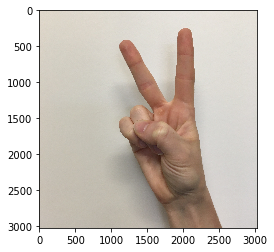

In [14]:
img_path = 'images/my_image.jpg'
img = image.load_img(img_path, target_size=(64, 64))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
print('Input image shape:', x.shape)
my_image = scipy.misc.imread(img_path)
imshow(my_image)
print("class prediction vector [p(0), p(1), p(2), p(3), p(4), p(5)] = ")
print(model.predict(x))

In [15]:
model.summary()

Model: "ResNet50"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_17 (InputLayer)           (None, 64, 64, 3)    0                                            
__________________________________________________________________________________________________
zero_padding2d_17 (ZeroPadding2 (None, 70, 70, 3)    0           input_17[0][0]                   
__________________________________________________________________________________________________
conv1 (Conv2D)                  (None, 33, 33, 64)   4864        zero_padding2d_17[0][0]          
__________________________________________________________________________________________________
bn_conv1 (BatchNormalization)   (None, 33, 33, 64)   256         conv1[0][0]                      
___________________________________________________________________________________________

In [16]:
plot_model(model, to_file='model.png')
SVG(model_to_dot(model).create(prog='dot', format='svg'))

OSError: `pydot` failed to call GraphViz.Please install GraphViz (https://www.graphviz.org/) and ensure that its executables are in the $PATH.

In [20]:
model.fit(X_train, Y_train, epochs = 20, batch_size = 16)

Epoch 1/20
1080/1080 [==============================] - 59s 55ms/step - loss: 3.3638 - accuracy: 0.5463
Epoch 2/20
1080/1080 [==============================] - 51s 47ms/step - loss: 2.7547 - accuracy: 0.3713
Epoch 3/20
1080/1080 [==============================] - 54s 50ms/step - loss: 1.6521 - accuracy: 0.5787
Epoch 4/20
1080/1080 [==============================] - 57s 53ms/step - loss: 1.3483 - accuracy: 0.6454
Epoch 5/20
1080/1080 [==============================] - 55s 51ms/step - loss: 1.5333 - accuracy: 0.6796
Epoch 6/20
1080/1080 [==============================] - 54s 50ms/step - loss: 1.2316 - accuracy: 0.6889
Epoch 7/20
1080/1080 [==============================] - 55s 51ms/step - loss: 0.9045 - accuracy: 0.7500
Epoch 8/20
1080/1080 [==============================] - 52s 49ms/step - loss: 0.6902 - accuracy: 0.8139
Epoch 9/20
1080/1080 [==============================] - 56s 52ms/step - loss: 0.6927 - accuracy: 0.8463
Epoch 10/20
1080/1080 [==============================] - 56s 52m

In [24]:
model.fit(X_train, Y_train, epochs = 20, batch_size = 8)

Epoch 1/20
1080/1080 [==============================] - 76s 70ms/step - loss: 0.9931 - accuracy: 0.7880
Epoch 2/20
1080/1080 [==============================] - 76s 71ms/step - loss: 0.7530 - accuracy: 0.8120
Epoch 3/20
1080/1080 [==============================] - 75s 69ms/step - loss: 0.4147 - accuracy: 0.8981
Epoch 4/20
1080/1080 [==============================] - 74s 69ms/step - loss: 0.6036 - accuracy: 0.8250
Epoch 5/20
1080/1080 [==============================] - 79s 73ms/step - loss: 0.4796 - accuracy: 0.8694
Epoch 6/20
1080/1080 [==============================] - 77s 71ms/step - loss: 0.2744 - accuracy: 0.9222
Epoch 7/20
1080/1080 [==============================] - 74s 69ms/step - loss: 0.2376 - accuracy: 0.9389
Epoch 8/20
1080/1080 [==============================] - 73s 68ms/step - loss: 0.1896 - accuracy: 0.9556
Epoch 9/20
1080/1080 [==============================] - 74s 68ms/step - loss: 0.2111 - accuracy: 0.9444
Epoch 10/20
1080/1080 [==============================] - 74s 69m

In [17]:
model.fit(X_train, Y_train, epochs = 20, batch_size = 4)

Epoch 1/20
1080/1080 [==============================] - 109s 101ms/step - loss: 4.8511 - accuracy: 0.2389
Epoch 2/20
1080/1080 [==============================] - 108s 100ms/step - loss: 2.8291 - accuracy: 0.3546
Epoch 3/20
1080/1080 [==============================] - 105s 97ms/step - loss: 2.0899 - accuracy: 0.4593
Epoch 4/20
1080/1080 [==============================] - 103s 95ms/step - loss: 2.3750 - accuracy: 0.4185
Epoch 5/20
1080/1080 [==============================] - 103s 95ms/step - loss: 2.2074 - accuracy: 0.4481
Epoch 6/20
1080/1080 [==============================] - 103s 96ms/step - loss: 1.6165 - accuracy: 0.5444
Epoch 7/20
1080/1080 [==============================] - 103s 96ms/step - loss: 1.5187 - accuracy: 0.5880
Epoch 8/20
1080/1080 [==============================] - 104s 96ms/step - loss: 1.2683 - accuracy: 0.6426
Epoch 9/20
1080/1080 [==============================] - 103s 95ms/step - loss: 0.9807 - accuracy: 0.7222
Epoch 10/20
1080/1080 [==============================